In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/raw/study_records.csv")

df.head()

,student_id,topic,exam_frequency,question_marks,difficulty,knowledge_before,study_minutes,quiz_before,quiz_after,exam_score
0,S001,TCP Congestion Control,9,10,8,25,90,30,82,86
1,S001,HTTP,8,8,6,40,60,45,88,91
2,S001,DNS,5,5,4,65,35,68,91,89
3,S001,Routing,8,8,7,30,60,35,78,84
4,S001,UDP,3,5,3,80,25,82,94,92


In [4]:
df.shape

(25, 10)

In [5]:
df.info

<bound method DataFrame.info of    student_id                   topic  exam_frequency  question_marks  \
0        S001  TCP Congestion Control               9              10   
1        S001                    HTTP               8               8   
2        S001                     DNS               5               5   
3        S001                 Routing               8               8   
4        S001                     UDP               3               5   
5        S002  TCP Congestion Control               9              10   
6        S002                    HTTP               8               8   
7        S002                     DNS               5               5   
8        S002                 Routing               8               8   
9        S002                     UDP               3               5   
10       S003  TCP Congestion Control               9              10   
11       S003                    HTTP               8               8   
12       S003      

In [6]:
df.describe

<bound method NDFrame.describe of    student_id                   topic  exam_frequency  question_marks  \
0        S001  TCP Congestion Control               9              10   
1        S001                    HTTP               8               8   
2        S001                     DNS               5               5   
3        S001                 Routing               8               8   
4        S001                     UDP               3               5   
5        S002  TCP Congestion Control               9              10   
6        S002                    HTTP               8               8   
7        S002                     DNS               5               5   
8        S002                 Routing               8               8   
9        S002                     UDP               3               5   
10       S003  TCP Congestion Control               9              10   
11       S003                    HTTP               8               8   
12       S003    

In [7]:
df.isnull().sum()

student_id          0
topic               0
exam_frequency      0
question_marks      0
difficulty          0
knowledge_before    0
study_minutes       0
quiz_before         0
quiz_after          0
exam_score          0
dtype: int64

In [9]:
df["learning_gain"] = (
    df["quiz_after"] - df["quiz_before"]
)

In [10]:
df[
    [
        "student_id",
        "topic",
        "quiz_before",
        "quiz_after",
        "learning_gain"
    ]
]

,student_id,topic,quiz_before,quiz_after,learning_gain
0,S001,TCP Congestion Control,30,82,52
1,S001,HTTP,45,88,43
2,S001,DNS,68,91,23
3,S001,Routing,35,78,43
4,S001,UDP,82,94,12
5,S002,TCP Congestion Control,45,85,40
6,S002,HTTP,25,78,53
7,S002,DNS,75,93,18
8,S002,Routing,40,80,40
9,S002,UDP,65,90,25


In [11]:
df["knowledge_gap"] = (
    100 - df["knowledge_before"]
)

In [12]:
df[
    [
        "topic",
        "knowledge_before",
        "knowledge_gap"
    ]
]

,topic,knowledge_before,knowledge_gap
0,TCP Congestion Control,25,75
1,HTTP,40,60
2,DNS,65,35
3,Routing,30,70
4,UDP,80,20
5,TCP Congestion Control,40,60
6,HTTP,20,80
7,DNS,70,30
8,Routing,35,65
9,UDP,60,40


In [13]:
df["priority_score"] = (
    df["exam_frequency"]
    * df["question_marks"]
    * df["knowledge_gap"]
)

In [15]:
df["priority_score_normalized"] = (
    df["priority_score"]
    /df["priority_score"].max()
) *100

In [16]:
df[
    [
        "topic",
        "priority_score",
        "priority_score_normalized"
    ]
]

,topic,priority_score,priority_score_normalized
0,TCP Congestion Control,6750,88.235294
1,HTTP,3840,50.196078
2,DNS,875,11.437908
3,Routing,4480,58.562092
4,UDP,300,3.921569
5,TCP Congestion Control,5400,70.588235
6,HTTP,5120,66.928105
7,DNS,750,9.803922
8,Routing,4160,54.379085
9,UDP,600,7.843137


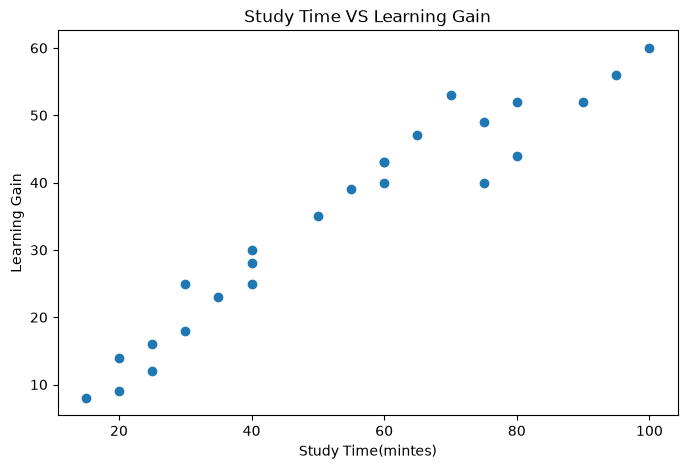

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["study_minutes"],
    df["learning_gain"]
)
plt.xlabel("Study Time(mintes)")
plt.ylabel("Learning Gain")
plt.title("Study Time VS Learning Gain")
plt.show()

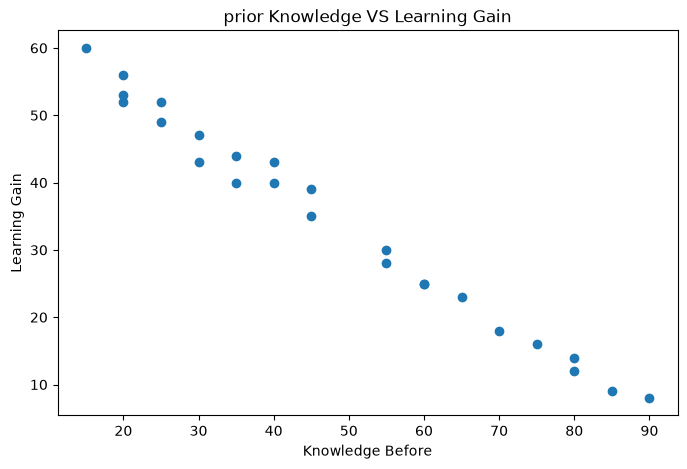

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["knowledge_before"],
    df["learning_gain"]
)
plt.xlabel("Knowledge Before")
plt.ylabel("Learning Gain")
plt.title("prior Knowledge VS Learning Gain")
plt.show()

In [22]:
topic_summary = df.groupby("topic").agg({
    "learning_gain": "mean",
    "study_minutes": "mean",
    "exam_score": "mean"
})
topic_summary

,learning_gain,study_minutes,exam_score
topic,,,
DNS,21.6,33.0,90.0
HTTP,42.4,58.0,89.0
Routing,43.8,65.0,85.0
TCP Congestion Control,50.4,88.0,85.8
UDP,14.0,23.0,92.8


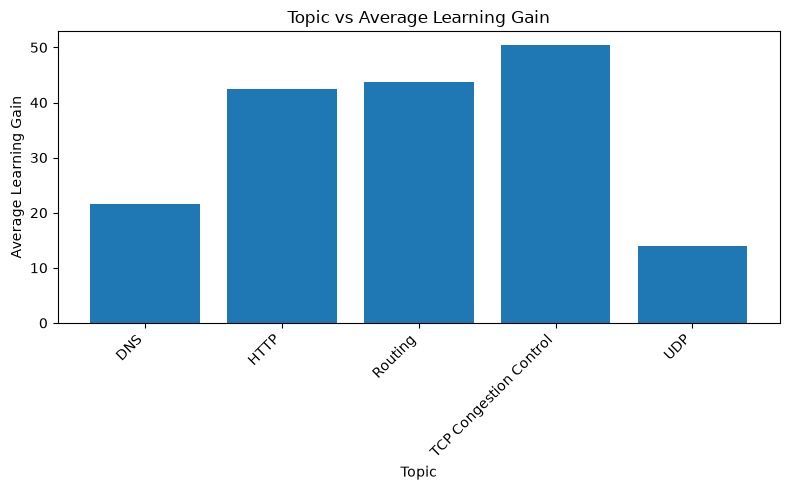

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    topic_summary.index,
    topic_summary["learning_gain"]
)

plt.xlabel("Topic")
plt.ylabel("Average Learning Gain")
plt.title("Topic vs Average Learning Gain")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## My Observations

1. More study time does not always produce higher learning gain.
2. Students with lower knowledge before studying generally show higher learning gains.
3. TCP Congestion Control has the highest average learning gain in this dataset.
4. UDP has a high average exam score but a relatively low learning gain.